In [1]:
import pandas as pd
import numpy as np
import math
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Read the Dataset
df2 = pd.read_csv("LoL_champions_encoded.csv").sample(frac=1)

In [2]:
# features_col2 = [
#     "Role_Top", "Role_Jungle", "Role_Middle", "Role_Bottom", "Role_Support", "Tag_Assassin",
#     "Tag_Fighter", "Tag_Mage", "Tag_Marksman", "Tag_Support", "Tag_Tank", "Is_Ranged",
#     "Res_Mana", "Res_Energy", "Res_Other", "Base HP", "HP per lvl", "Base mana",
#     "Mana per lvl", "Movement speed", "Base armor", "Armor per lvl", "Base magic resistance", "Magic resistance per lvl",
#     "Attack range", "HP regeneration", "HP regeneration per lvl", "Mana regeneration", "Mana regeneration per lvl", "Attack damage",
#     "Attack damage per lvl", "Attack speed per lvl", "Attack speed", "AS ratio"
# ]

features_col2 = [
    # "Role_Top", "Role_Jungle", "Role_Middle", "Role_Bottom", "Role_Support", 
    # "Tag_Assassin", "Tag_Fighter", "Tag_Mage", "Tag_Marksman", "Tag_Support", "Tag_Tank", 
    # "Is_Ranged", 
    # "Res_Mana", "Res_Energy", "Res_Other", 
    "Base HP", "HP per lvl", "Base mana",
    "Mana per lvl", "Movement speed", "Base armor", "Armor per lvl", "Base magic resistance", "Magic resistance per lvl",
    "Attack range", "HP regeneration", "HP regeneration per lvl", "Mana regeneration", "Mana regeneration per lvl", "Attack damage",
    "Attack damage per lvl", "Attack speed per lvl", "Attack speed", "AS ratio"
]

# Get feature values
features2 = df2[features_col2].values

# Min max norm for df 2
col_min2 = features2.min(axis=0)
col_max2 = features2.max(axis=0)
col_range2 = col_max2 - col_min2
feature_norm2 = (features2 - col_min2) / col_range2

# # Z-score norm
# col_mean2 = features2.mean(axis=0)
# col_std2 = features2.std(axis=0)
# feature_norm2 = (features2 - col_mean2) / col_std2

# Get names
names2 = df2["Name"].tolist()

# Incase we want to change the sample size
n2 = len(feature_norm2)

# Just to see what we are working with
df_norm2 = pd.DataFrame(feature_norm2, columns=features_col2, index=names2)
df_norm2.head()

,Base HP,HP per lvl,Base mana,Mana per lvl,Movement speed,Base armor,Armor per lvl,Base magic resistance,Magic resistance per lvl,Attack range,HP regeneration,HP regeneration per lvl,Mana regeneration,Mana regeneration per lvl,Attack damage,Attack damage per lvl,Attack speed per lvl,Attack speed,AS ratio
Milio,0.524476,0.316667,0.688679,0.494253,0.166667,0.275862,0.836364,0.470588,0.137931,0.761905,0.50,0.40,0.23,0.40,0.16,0.64,0.500000,0.400000,0.735294
Ahri,0.629371,0.583333,0.788679,0.287356,0.166667,0.103448,0.854545,0.470588,0.137931,0.809524,0.25,0.48,0.16,0.80,0.36,0.60,0.366667,0.514667,0.735294
Sona,0.489510,0.366667,0.641509,0.517241,0.000000,0.275862,0.763636,0.470588,0.137931,0.809524,0.55,0.44,0.23,0.40,0.20,0.60,0.383333,0.450667,0.757647
Hwei,0.594406,0.666667,0.905660,0.344828,0.166667,0.103448,0.854545,0.470588,0.137931,0.809524,0.55,0.44,0.15,0.75,0.40,0.66,0.416667,0.573333,0.774118
Gwen,0.734266,0.766667,0.622642,0.459770,0.500000,0.724138,0.945455,0.588235,0.655172,0.047619,0.90,0.72,0.15,0.70,0.76,0.60,0.375000,0.573333,0.811765


In [3]:
# Set up distance matrix and make it all 0
distance_matrix2 = [[0.0 for _ in range(n2)] for _ in range(n2)]

# Calculating distances Euclidean 
for i in range(n2):
    for j in range(i+1, n2):
        diff = feature_norm2[i] - feature_norm2[j]
        distance = math.sqrt((diff ** 2).sum())
        distance_matrix2[i][j] = distance
        distance_matrix2[j][i] = distance

# # Calculating distances Manhattan 
# for i in range(n2):
#     for j in range(i+1, n2):
#         diff = feature_norm2[i] - feature_norm2[j]
#         distance = np.sum(np.abs(diff))
#         distance_matrix2[i][j] = distance
#         distance_matrix2[j][i] = distance

<function matplotlib.pyplot.show(close=None, block=None)>

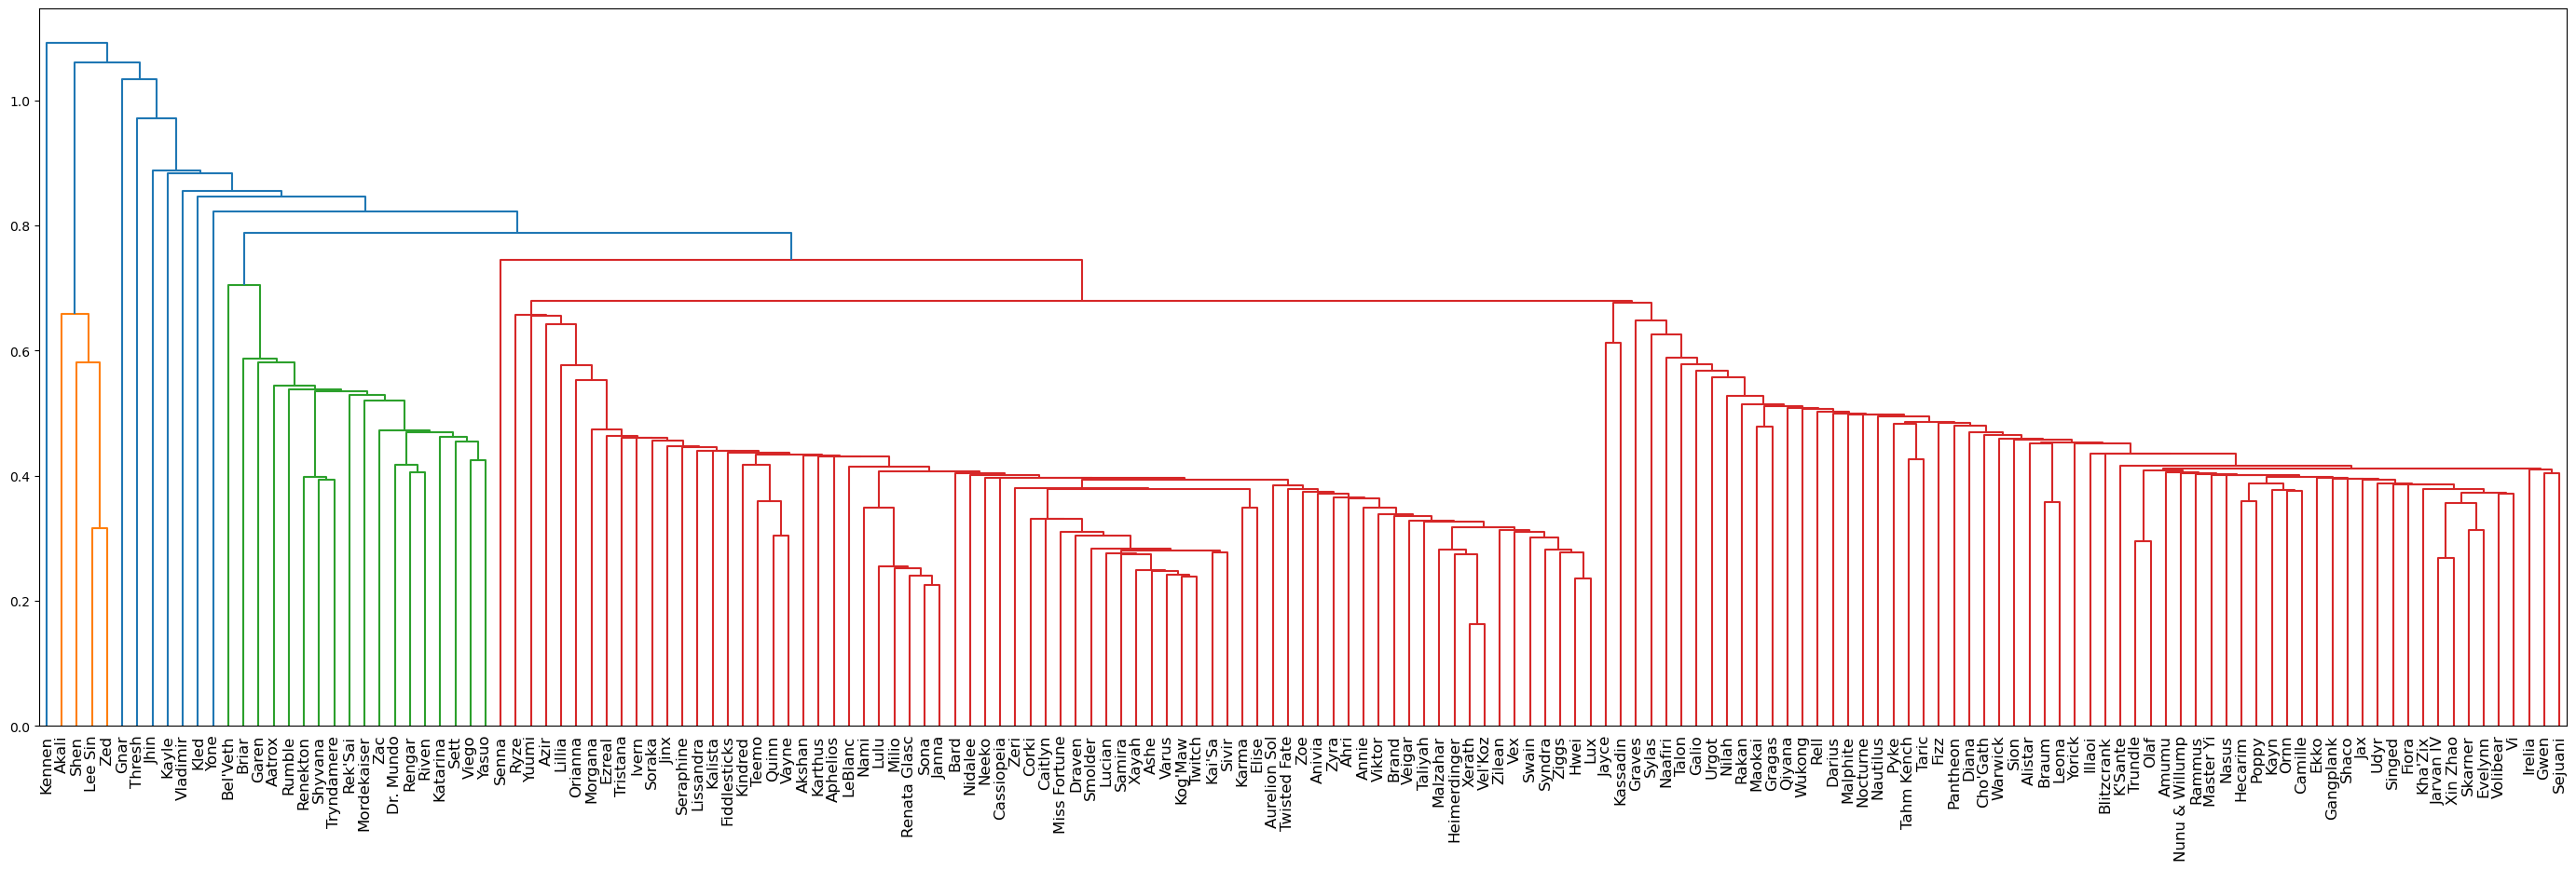

In [4]:
dists2 = squareform(distance_matrix2)
linkage_matrix2 = linkage(dists2, "single")
plt.figure(figsize=(35, 10))
dendrogram(
    linkage_matrix2,
    labels=names2,
    leaf_font_size=12
)
plt.show